# 04. Modeling, Evaluation, and Report Figures

Run strict temporal modeling with graph-only, text-only, history-only, no-balance, and hybrid feature sets. Export metrics, feature importance, prediction scores, and report-ready figures. The target is a future negative-dominant source-target relationship: `future_negative_count > future_positive_count`.

In [1]:
from pathlib import Path
import importlib
import sys

root = Path.cwd()
if not (root / 'data').exists():
    root = root.parent
sys.path.insert(0, str(root))

import src.phase3 as phase3
from src.visualization import export_report_figures
phase3 = importlib.reload(phase3)

phase1_path = root / 'data' / 'processed' / 'phase1' / 'phase1_kcore_filtered.csv'
phase3_dir = root / 'data' / 'processed' / 'phase3'
figure_dir = root / 'reports' / 'figures'
phase3_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
phase1_path

WindowsPath('H:/chuong_trinh_hoc_UEH/mon_hoc_ki_6/social_media_data_analysis/Project/Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning/data/processed/phase1/phase1_kcore_filtered.csv')

In [2]:
interactions = phase3.load_phase1_interactions(phase1_path)
metrics_frame, importance_frame, score_frame, splits = phase3.run_phase3_pipeline(interactions)
paths = phase3.export_phase3_outputs(metrics_frame, importance_frame, phase3_dir, score_frame)
figure_paths = export_report_figures(interactions, metrics_frame, importance_frame, figure_dir, score_frame)

{
    'train_rows': len(splits.train),
    'validation_rows': len(splits.validation),
    'test_rows': len(splits.test),
    'metric_rows': len(metrics_frame),
    'models': sorted(metrics_frame['model'].unique().tolist()),
    'feature_sets': sorted(metrics_frame['feature_set'].unique().tolist()),
    'importance_rows': len(importance_frame),
    'score_rows': len(score_frame),
    'export_paths': {key: str(value) for key, value in paths.items()},
    'figure_count': len(figure_paths),
}

{'train_rows': 25045,
 'validation_rows': 26450,
 'test_rows': 24185,
 'metric_rows': 41,
 'models': ['dummy_most_frequent',
  'dummy_prior',
  'historical_negative_ratio',
  'lightgbm',
  'logistic_regression',
  'random_forest',
  'xgboost'],
 'feature_sets': ['graph_no_balance',
  'graph_only',
  'history_only',
  'hybrid',
  'hybrid_no_balance',
  'text_only'],
 'importance_rows': 2634,
 'score_rows': 2076035,
 'export_paths': {'metrics': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase3\\phase3_model_metrics.csv',
  'importance': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase3\\phase3_feature_importance.csv',
  'scores': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Lin

In [3]:
metric_columns = [
    'feature_set', 'model',
    'test_pr_auc', 'test_roc_auc', 'test_f1', 'test_macro_f1',
    'test_precision', 'test_recall', 'test_balanced_accuracy', 'test_accuracy',
    'test_threshold', 'test_tn', 'test_fp', 'test_fn', 'test_tp', 'n_features',
]
metrics_frame[metric_columns].head(50)

,feature_set,model,test_pr_auc,test_roc_auc,test_f1,test_macro_f1,test_precision,test_recall,test_balanced_accuracy,test_accuracy,test_threshold,test_tn,test_fp,test_fn,test_tp,n_features
0,hybrid,logistic_regression,0.183964,0.756892,0.269986,0.593465,0.204978,0.395376,0.640194,0.850858,0.72,19911,2587,1020,667,133
1,hybrid_no_balance,logistic_regression,0.183635,0.756049,0.266920,0.593611,0.207134,0.375222,0.633762,0.856233,0.73,20075,2423,1054,633,128
2,graph_only,logistic_regression,0.181181,0.750819,0.262482,0.577535,0.180861,0.478364,0.657953,0.812487,0.63,18843,3655,880,807,44
3,graph_no_balance,logistic_regression,0.180749,0.749552,0.264291,0.572640,0.176307,0.527564,0.671374,0.795121,0.60,18340,4158,797,890,39
4,hybrid,lightgbm,0.179214,0.762595,0.256013,0.584824,0.192584,0.381743,0.630866,0.845235,0.19,19798,2700,1043,644,133
5,graph_no_balance,lightgbm,0.178420,0.760506,0.260528,0.574248,0.177250,0.491405,0.660184,0.805417,0.17,18650,3848,858,829,39
6,graph_only,lightgbm,0.177255,0.759236,0.249907,0.577959,0.181941,0.398933,0.632216,0.832954,0.19,19472,3026,1014,673,44
7,hybrid,xgboost,0.175451,0.753152,0.234777,0.575442,0.181436,0.332543,0.610022,0.848791,0.20,19967,2531,1126,561,133
8,graph_only,xgboost,0.174134,0.756554,0.253587,0.578165,0.181795,0.419087,0.638826,0.827910,0.20,19316,3182,980,707,44
9,hybrid_no_balance,lightgbm,0.173634,0.760980,0.259302,0.576737,0.179817,0.464730,0.652891,0.814803,0.16,18922,3576,903,784,128


In [4]:
non_baseline = metrics_frame[
    ~metrics_frame['model'].str.startswith('dummy')
    & (metrics_frame['model'] != 'historical_negative_ratio')
]
best_row = non_baseline.sort_values(['test_pr_auc', 'test_f1'], ascending=False).iloc[0]
best_importance = (
    importance_frame[
        (importance_frame['feature_set'] == best_row['feature_set'])
        & (importance_frame['model'] == best_row['model'])
    ]
    .sort_values('importance', ascending=False)
    .head(30)
)
{
    'best_feature_set': best_row['feature_set'],
    'best_model': best_row['model'],
    'test_pr_auc': float(best_row['test_pr_auc']),
    'top_features': best_importance[['feature', 'importance']].to_dict('records'),
}

{'best_feature_set': 'hybrid',
 'best_model': 'logistic_regression',
 'test_pr_auc': 0.18396441275339429,
 'top_features': [{'feature': 'text_property_16',
   'importance': 4.459202948569771},
  {'feature': 'text_property_17', 'importance': 3.9829605188077815},
  {'feature': 'source_out_positive_degree', 'importance': 2.9736845938307623},
  {'feature': 'source_out_degree', 'importance': 2.388683996014026},
  {'feature': 'source_out_negative_degree', 'importance': 1.7504222830494927},
  {'feature': 'target_in_positive_degree', 'importance': 1.7495398395143242},
  {'feature': 'source_total_degree', 'importance': 1.728504899142349},
  {'feature': 'text_property_10', 'importance': 1.3001767921021334},
  {'feature': 'text_property_47', 'importance': 0.8870301440457319},
  {'feature': 'target_in_degree', 'importance': 0.8708105570829926},
  {'feature': 'target_community_negative_ratio',
   'importance': 0.860222423969312},
  {'feature': 'source_in_degree', 'importance': 0.8052351416886037},


## Direct Report Figures

The generated report figures are displayed below so the notebook is self-contained for review.

model_comparison_pr_auc.png


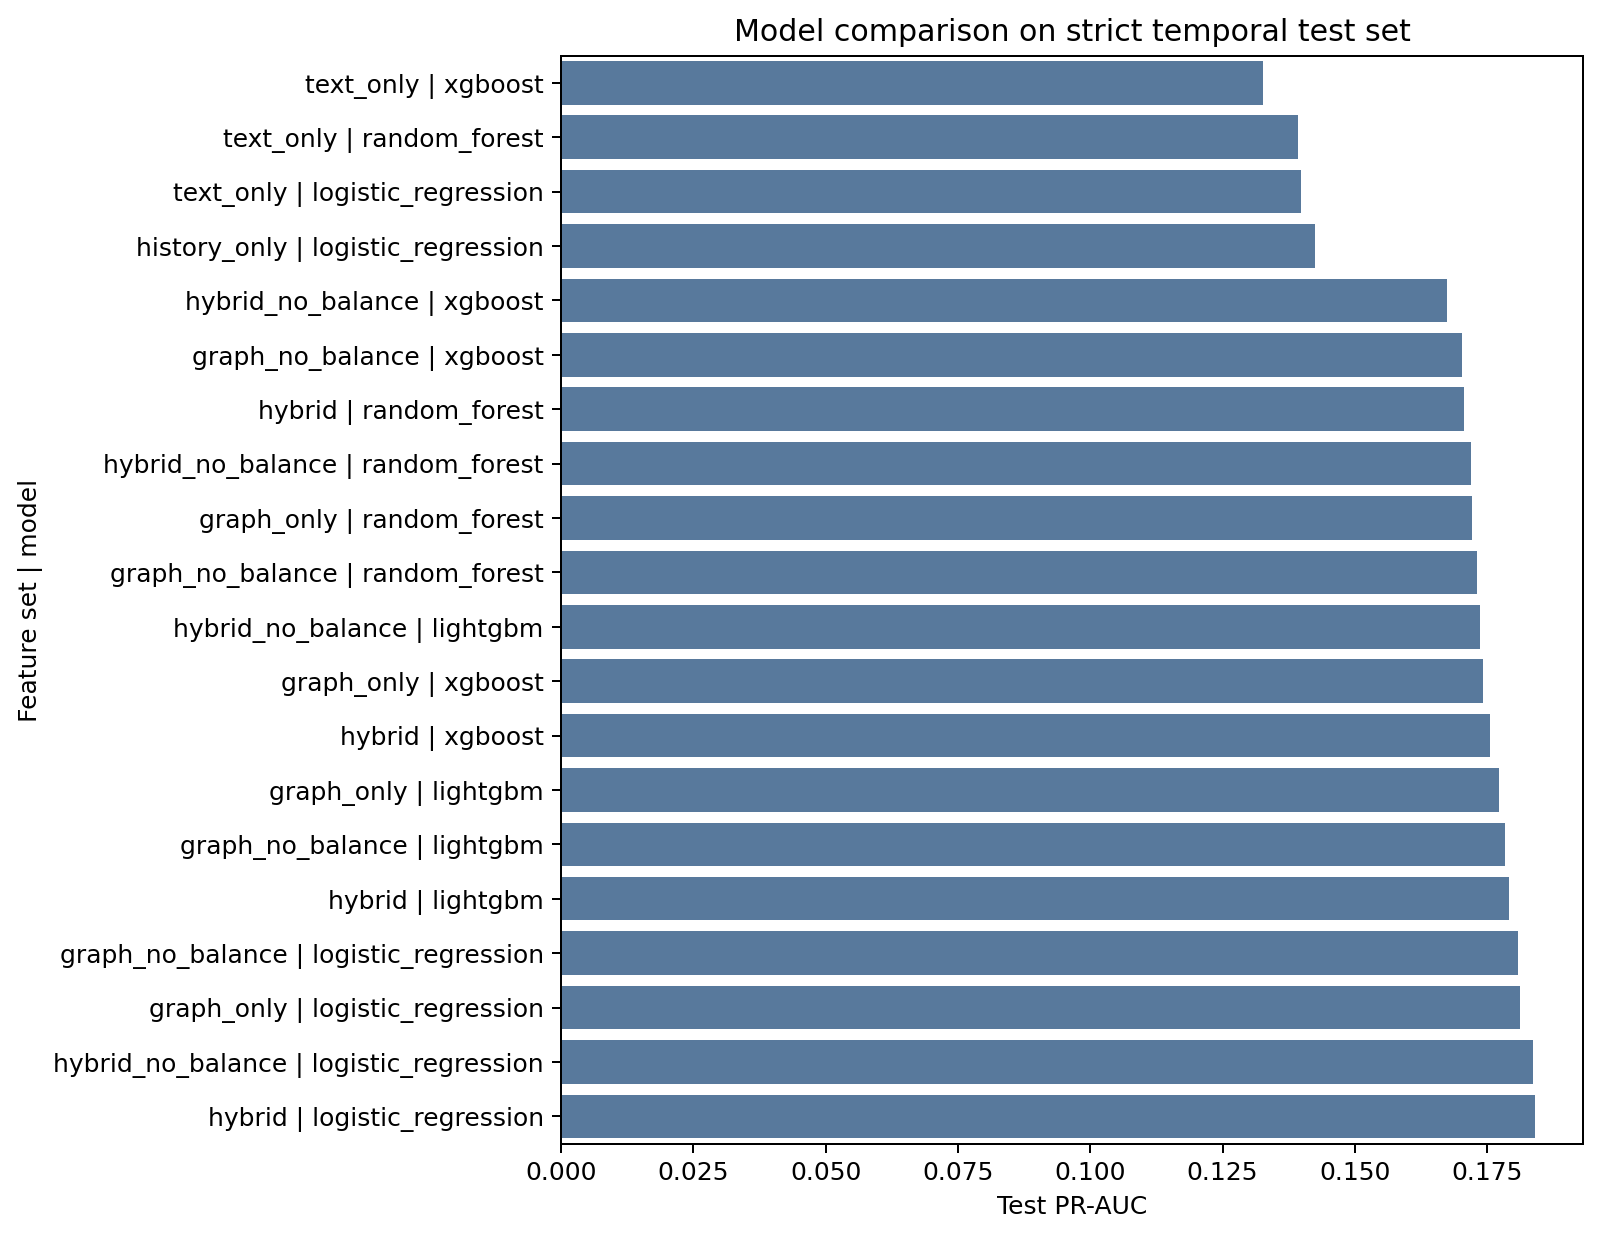

precision_recall_curve.png


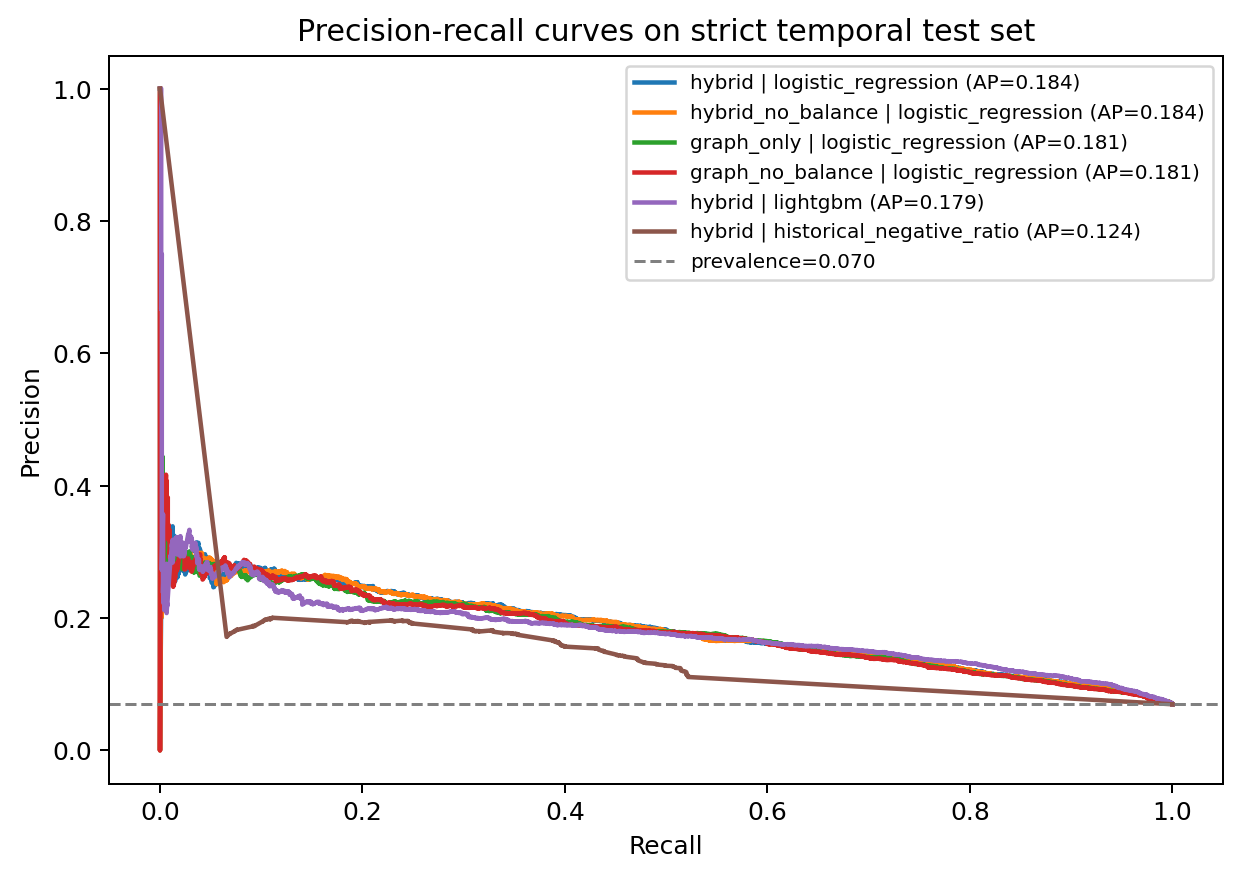

roc_curve.png


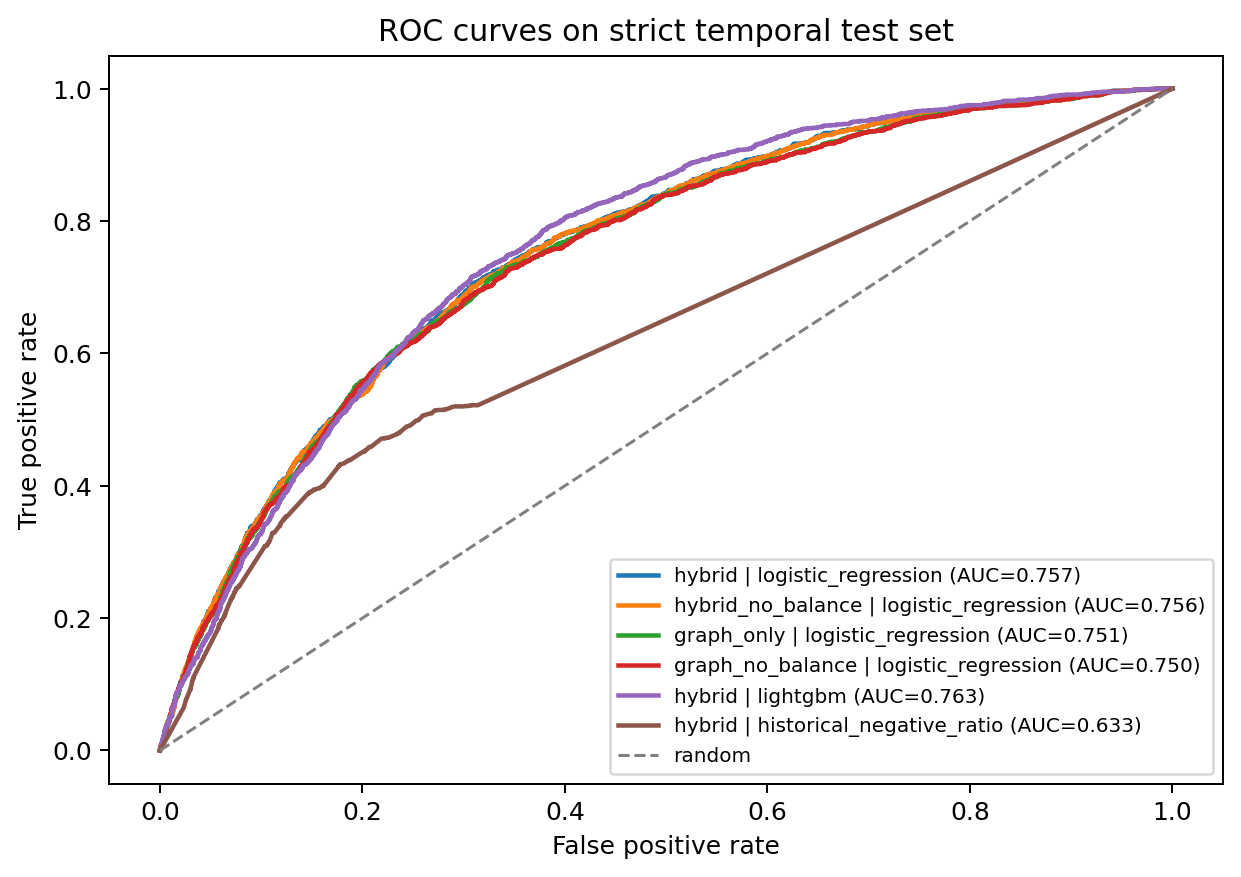

best_confusion_matrix.png


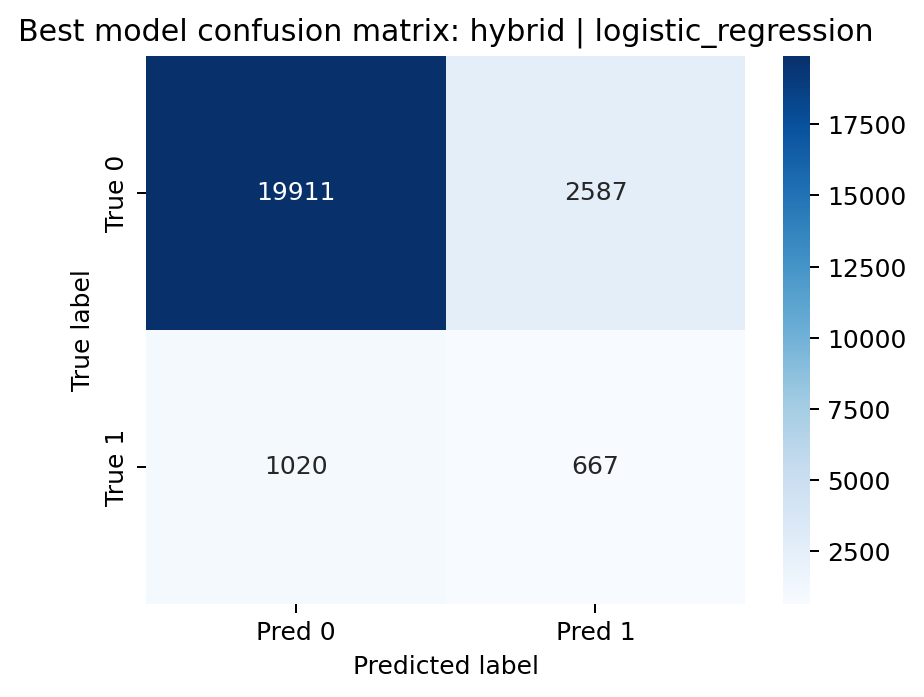

feature_importance_top20.png


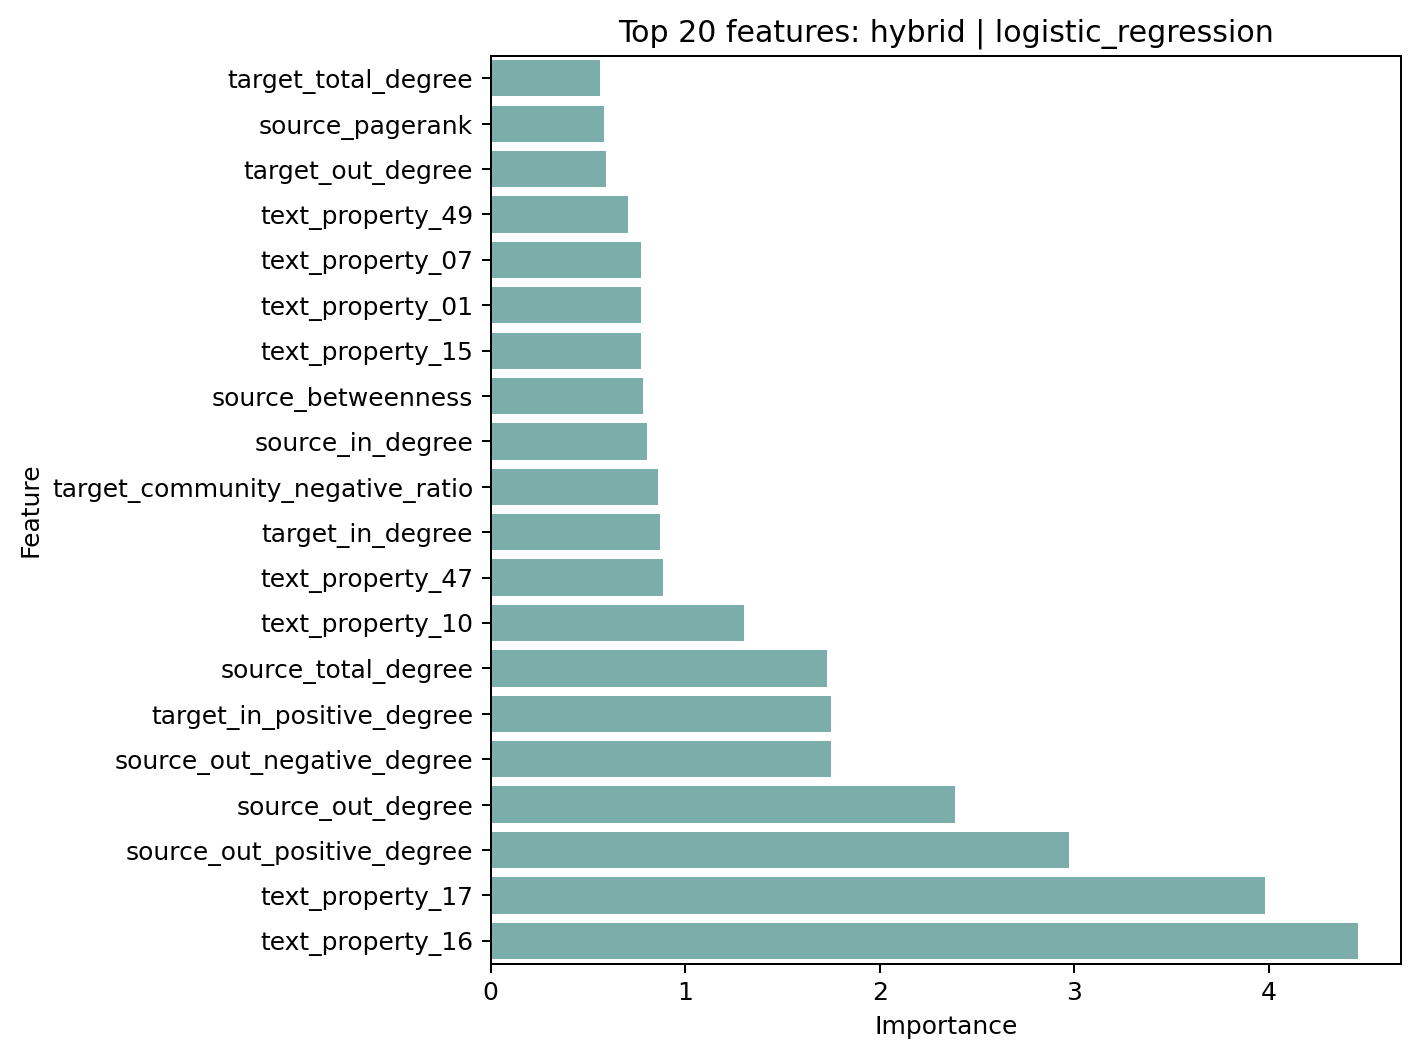

label_distribution.png


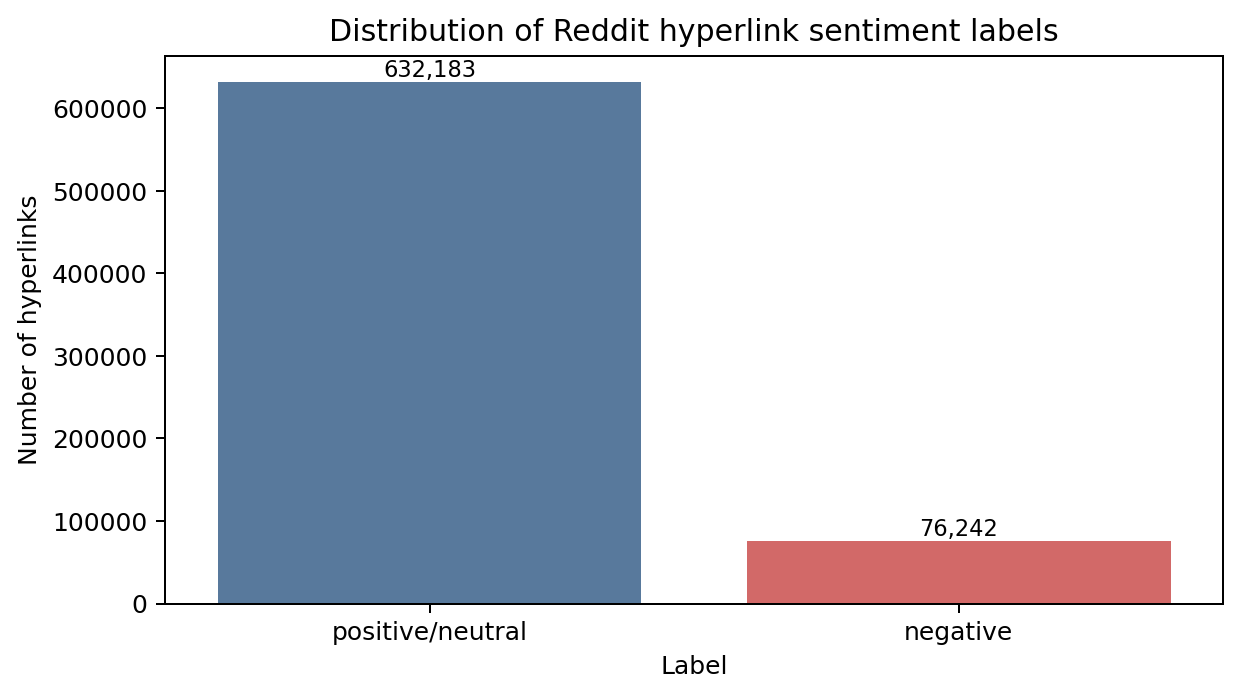

monthly_negative_ratio.png


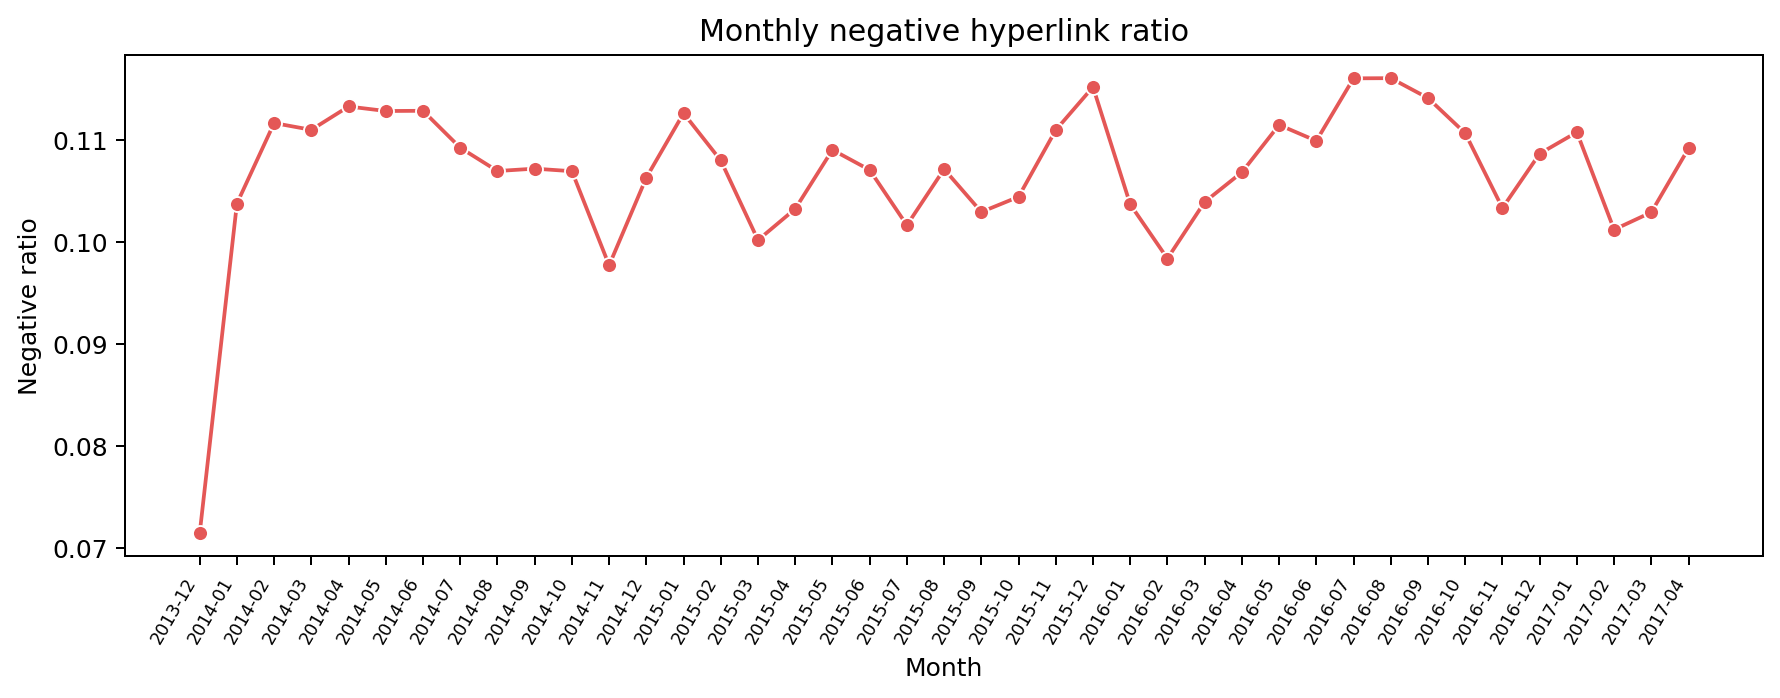

top_negative_sources.png


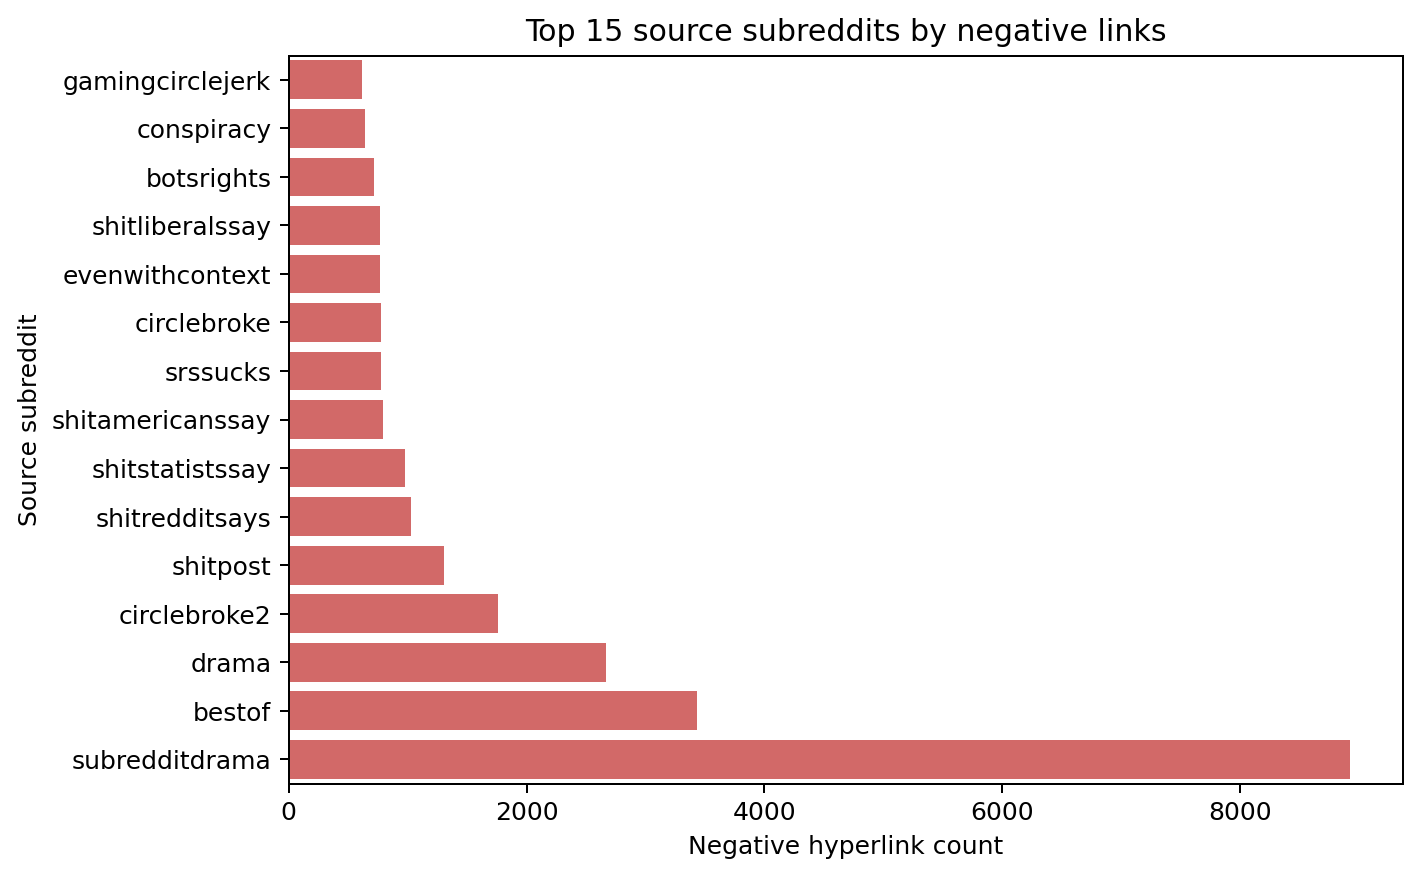

top_negative_targets.png


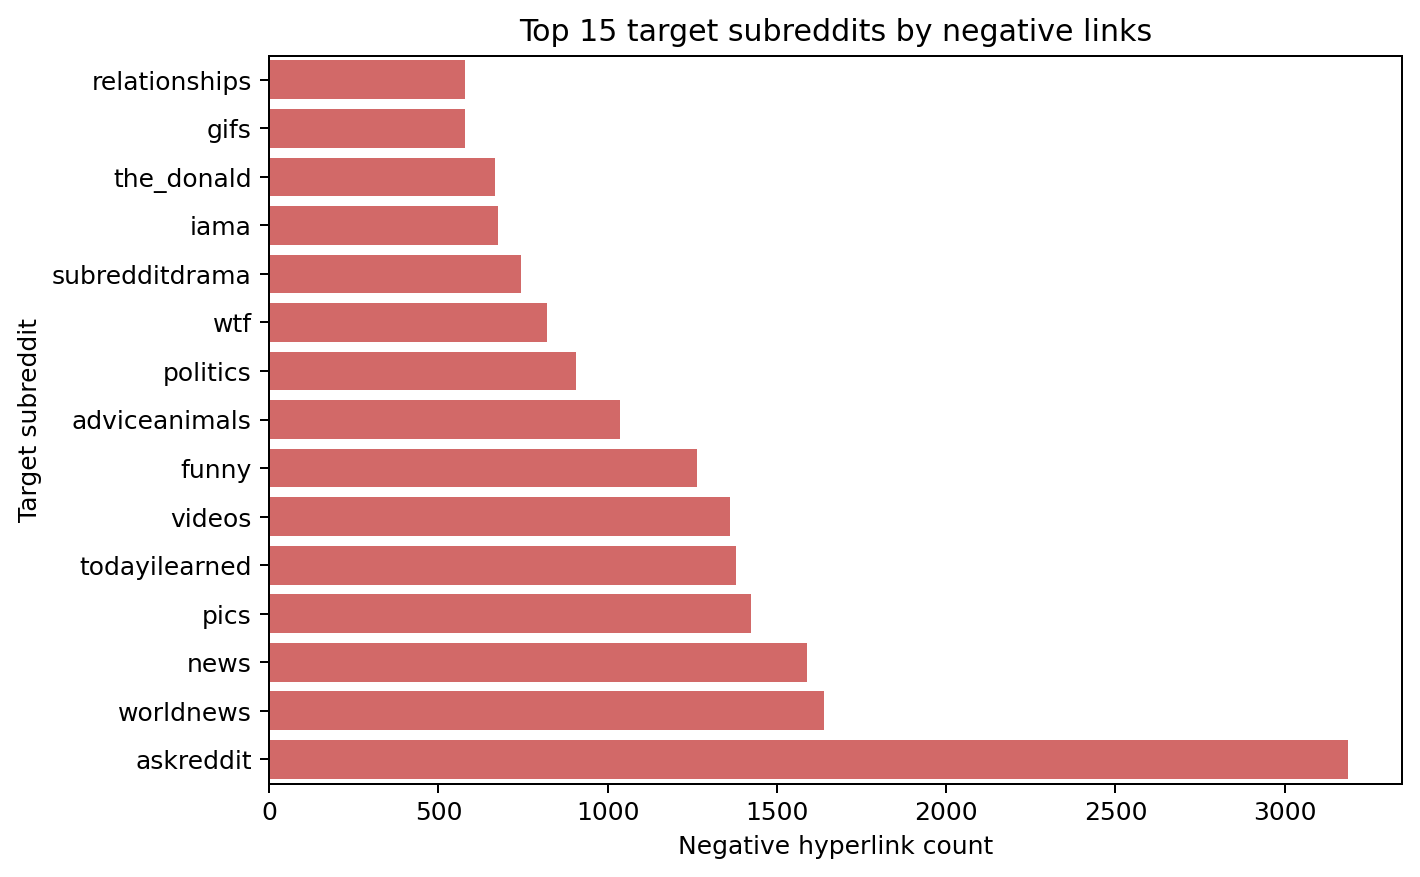

degree_distribution.png


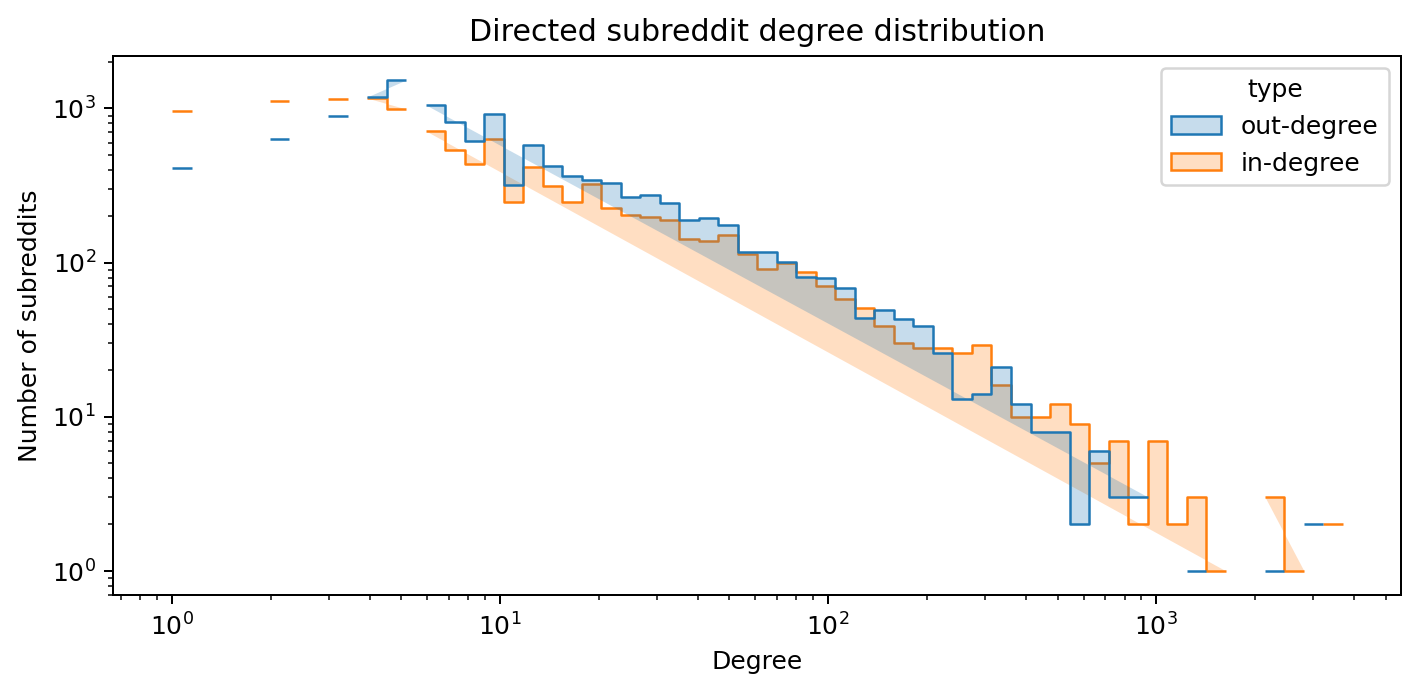

In [5]:
from IPython.display import display, Image

for image_name in [
    'model_comparison_pr_auc.png',
    'precision_recall_curve.png',
    'roc_curve.png',
    'best_confusion_matrix.png',
    'feature_importance_top20.png',
    'label_distribution.png',
    'monthly_negative_ratio.png',
    'top_negative_sources.png',
    'top_negative_targets.png',
    'degree_distribution.png',
]:
    path = figure_dir / image_name
    print(path.name)
    display(Image(filename=str(path)))